# Detección de comunidades en Twitter con Louvain + PySpark

**Dataset:** `cache-0-json.gz` — tweets en formato JSON de la Twitter API v1  
**Objetivo:** Construir un grafo de interacciones (menciones + retweets + replies), detectar comunidades con el algoritmo de Louvain paralelizado con Spark, y visualizarlas.

**Columnas disponibles en el dataset:**  
`text`, `in_reply_to_user_id`, `truncated`, `id_str`, `retweeted`, `in_reply_to_status_id_str`,  
`source`, `possibly_sensitive`, `entities`, `in_reply_to_screen_name`, `in_reply_to_status_id`,  
`in_reply_to_user_id_str`, `place`, `contributors`, `coordinates`, `created_at`, `favorited`,  
`possibly_sensitive_editable`, `user`, `retweet_count`, `id`, `geo`

## Requisitos previos
```bash
pip install pyspark python-louvain networkx matplotlib pandas requests tqdm
```
También necesitas **Java 8 o 11** instalado.  
En Windows: descárgalo desde https://adoptium.net y añade `JAVA_HOME` a tus variables de entorno.

## 0. Instalación de dependencias

In [3]:
import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "pyspark", "python-louvain", "networkx",
     "matplotlib", "pandas", "requests", "tqdm"],
    check=True
)

CompletedProcess(args=['c:\\Users\\mroje\\Desktop\\BigData2\\.venv\\Scripts\\python.exe', '-m', 'pip', 'install', 'pyspark', 'python-louvain', 'networkx', 'matplotlib', 'pandas', 'requests', 'tqdm'], returncode=0)

## 1. Descarga del dataset

In [4]:
import os
import requests
from tqdm import tqdm
from pathlib import Path

DATASET_URL = (
    "https://web.archive.org/web/20180417213757/"
    "https://ckannet-storage.commondatastorage.googleapis.com/"
    "2015-07-09T02:10:43.036Z/cache-0-json.gz"
)
DATA_DIR = Path("data")
GZ_PATH  = DATA_DIR / "cache-0-json.gz"

DATA_DIR.mkdir(exist_ok=True)

#if GZ_PATH.exists():
#    print(f"✓ Dataset ya descargado: {GZ_PATH} ({GZ_PATH.stat().st_size / 1e6:.1f} MB)")
#else:
#    print("Descargando dataset...")
#    headers = {"User-Agent": "Mozilla/5.0"}
#    with requests.get(DATASET_URL, headers=headers, stream=True, timeout=120) as r:
#        r.raise_for_status()
#        total = int(r.headers.get("content-length", 0))
#        with open(GZ_PATH, "wb") as f, tqdm(
#            total=total, unit="B", unit_scale=True, desc="cache-0-json.gz"
#        ) as bar:
#            for chunk in r.iter_content(chunk_size=1024 * 256):
#                f.write(chunk)
#                bar.update(len(chunk))
#    print(f"✓ Descargado: {GZ_PATH} ({GZ_PATH.stat().st_size / 1e6:.1f} MB)")

## 2. Exploración rápida del dataset (sin Spark)

In [5]:
import gzip, json

print("Inspeccionando las primeras líneas del archivo...\n")
samples = []

with gzip.open(GZ_PATH, "rt", encoding="utf-8", errors="replace") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line or line in ("[", "]", ","):
            continue
        clean = line.rstrip(",")
        try:
            obj = json.loads(clean)
            if isinstance(obj, dict) and ("id_str" in obj or "id" in obj):
                samples.append(obj)
            if len(samples) >= 3:
                break
        except json.JSONDecodeError:
            pass
        if i > 100:
            break

if samples:
    t = samples[0]
    print(f"Columnas del tweet : {list(t.keys())}")
    print(f"\nEjemplo de tweet:")
    print(f"  id_str       : {t.get('id_str')}")
    print(f"  text         : {str(t.get('text', ''))[:100]}")
    print(f"  retweeted    : {t.get('retweeted')}")
    print(f"  retweet_count: {t.get('retweet_count')}")
    print(f"  favorited    : {t.get('favorited')}")
    print(f"  user.lang    : {t.get('user', {}).get('lang')}")
    print(f"  user.screen  : @{t.get('user', {}).get('screen_name')}")
    print(f"  menciones    : {[m.get('id_str') for m in t.get('entities', {}).get('user_mentions', [])]}")
    print(f"  hashtags     : {[h.get('text') for h in t.get('entities', {}).get('hashtags', [])]}")
    print(f"  geo          : {t.get('geo')}")
    print(f"  place        : {t.get('place')}")
    print(f"  Es RT (texto): {str(t.get('text', '')).startswith('RT @')}")
else:
    print("⚠ No se pudieron parsear muestras. Verifica el formato del archivo.")

Inspeccionando las primeras líneas del archivo...

Columnas del tweet : ['text', 'in_reply_to_user_id', 'truncated', 'id_str', 'retweeted', 'in_reply_to_status_id_str', 'source', 'possibly_sensitive', 'entities', 'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_user_id_str', 'place', 'contributors', 'coordinates', 'created_at', 'favorited', 'possibly_sensitive_editable', 'user', 'retweet_count', 'id', 'geo']

Ejemplo de tweet:
  id_str       : 244907511377965056
  text         : Obama vies for health care edge in Florida - http://t.co/OcISvreb http://t.co/FsJ7xgGW #florida
  retweeted    : False
  retweet_count: 0
  favorited    : False
  user.lang    : en
  user.screen  : @FLnewswire
  menciones    : []
  hashtags     : ['florida']
  geo          : None
  place        : None
  Es RT (texto): False


## 3. Convertir a JSON-Lines

In [6]:
JSONL_PATH = DATA_DIR / "tweets.jsonl"

#if not JSONL_PATH.exists():
#    print("Convirtiendo a JSON-Lines (una línea por tweet)...")
#    converted = 0
#    with gzip.open(GZ_PATH, "rt", encoding="utf-8", errors="replace") as fin, \
#         open(JSONL_PATH, "w", encoding="utf-8") as fout:
#        buffer = ""
#        for line in fin:
#            line = line.strip()
#            if not line or line in ("[", "]"):
#                continue
#            clean = line.rstrip(",")
#            try:
#                obj = json.loads(clean)
#                if isinstance(obj, dict) and ("id_str" in obj or "id" in obj):
#                    fout.write(json.dumps(obj) + "\n")
#                    converted += 1
#                elif isinstance(obj, list):
#                    for item in obj:
#                        fout.write(json.dumps(item) + "\n")
#                        converted += 1
#            except json.JSONDecodeError:
#                buffer += clean
#                try:
#                    obj = json.loads(buffer)
#                    fout.write(json.dumps(obj) + "\n")
#                    converted += 1
#                    buffer = ""
#                except:
#                    pass
#    print(f"✓ {converted:,} tweets escritos en {JSONL_PATH}")
#else:
#    print(f"✓ JSONL ya existe: {JSONL_PATH}")

## 4. Inicializar Spark

In [7]:
import os, sys
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# En Windows, Spark necesita winutils.exe
# Descárgalo de: https://github.com/steveloughran/winutils
# Colócalo en C:\hadoop\bin\winutils.exe y descomenta:
# os.environ["HADOOP_HOME"] = r"C:\hadoop"

os.environ["PYSPARK_PYTHON"] = sys.executable

spark = (
    SparkSession.builder
    .appName("LouvainTweets")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"✓ Spark {spark.version} iniciado — {spark.sparkContext.defaultParallelism} cores")

raw_df = spark.read.json(str(JSONL_PATH))
total_tweets = raw_df.count()
print(f"✓ Dataset cargado: {total_tweets:,} tweets")
print(f"Columnas: {raw_df.columns}")

✓ Spark 4.0.0 iniciado — 16 cores
✓ Dataset cargado: 1,000,000 tweets
Columnas: ['contributors', 'coordinates', 'created_at', 'entities', 'favorited', 'geo', 'id', 'id_str', 'in_reply_to_screen_name', 'in_reply_to_status_id', 'in_reply_to_status_id_str', 'in_reply_to_user_id', 'in_reply_to_user_id_str', 'place', 'possibly_sensitive', 'possibly_sensitive_editable', 'retweet_count', 'retweeted', 'retweeted_status', 'source', 'text', 'truncated', 'user']


## 5. Selección de campos y estadísticas básicas

**Adaptaciones respecto al schema estándar de Twitter API v1.1:**
- `lang` → no existe en raíz; se extrae de `user.lang`
- `favorite_count` → no existe; se usa el booleano `favorited`
- `retweeted_status` → no existe; los RT se detectan por `text.startswith('RT @')`

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

tweets_df = raw_df.select(
    F.col("id_str").alias("tweet_id"),
    F.col("text"),
    F.col("created_at"),
    F.col("retweet_count"),
    F.col("retweeted"),                                      # booleano
    F.col("favorited"),                                      # booleano
    F.col("truncated"),
    F.col("source"),
    F.col("possibly_sensitive"),
    # Campos de reply
    F.col("in_reply_to_user_id_str").alias("reply_to_user_id"),
    F.col("in_reply_to_screen_name").alias("reply_to_screen_name"),
    F.col("in_reply_to_status_id_str").alias("reply_to_tweet_id"),
    # Campos de usuario
    F.col("user.id_str").alias("user_id"),
    F.col("user.screen_name").alias("screen_name"),
    F.col("user.followers_count").alias("followers"),
    F.col("user.friends_count").alias("following"),
    F.col("user.statuses_count").alias("tweet_count"),
    F.col("user.lang").alias("lang"),                       # idioma del usuario
    F.col("user.verified").alias("verified"),
    # Entidades
    F.col("entities.user_mentions").alias("mentions"),
    F.col("entities.hashtags").alias("hashtags"),
    F.col("entities.urls").alias("urls"),
    # Geo
    F.col("geo"),
    F.col("coordinates"),
    F.col("place"),
    # Detectar RT por texto (más fiable que el campo 'retweeted')
    F.col("text").startswith("RT @").alias("is_retweet"),
    # Extraer screen_name del autor original del RT
    F.regexp_extract(F.col("text"), r"^RT @([^:]+):", 1).alias("rt_source_name"),
).cache()

print("=== Estadísticas del dataset ===")
print(f"Total tweets        : {tweets_df.count():>10,}")
print(f"Usuarios únicos     : {tweets_df.select('user_id').distinct().count():>10,}")
print(f"Retweets (RT @)     : {tweets_df.filter(F.col('is_retweet')).count():>10,}")
print(f"Replies             : {tweets_df.filter(F.col('reply_to_user_id').isNotNull()).count():>10,}")
print(f"Con menciones       : {tweets_df.filter(F.size('mentions') > 0).count():>10,}")
print(f"Con hashtags        : {tweets_df.filter(F.size('hashtags') > 0).count():>10,}")
print(f"Con geolocalización : {tweets_df.filter(F.col('geo').isNotNull()).count():>10,}")
print(f"Usuarios verificados: {tweets_df.filter(F.col('verified') == True).select('user_id').distinct().count():>10,}")

=== Estadísticas del dataset ===
Total tweets        :  1,000,000
Usuarios únicos     :    580,370
Retweets (RT @)     :    427,283
Replies             :    103,991
Con menciones       :    613,097
Con hashtags        :    227,029
Con geolocalización :      5,999
Usuarios verificados:      1,494


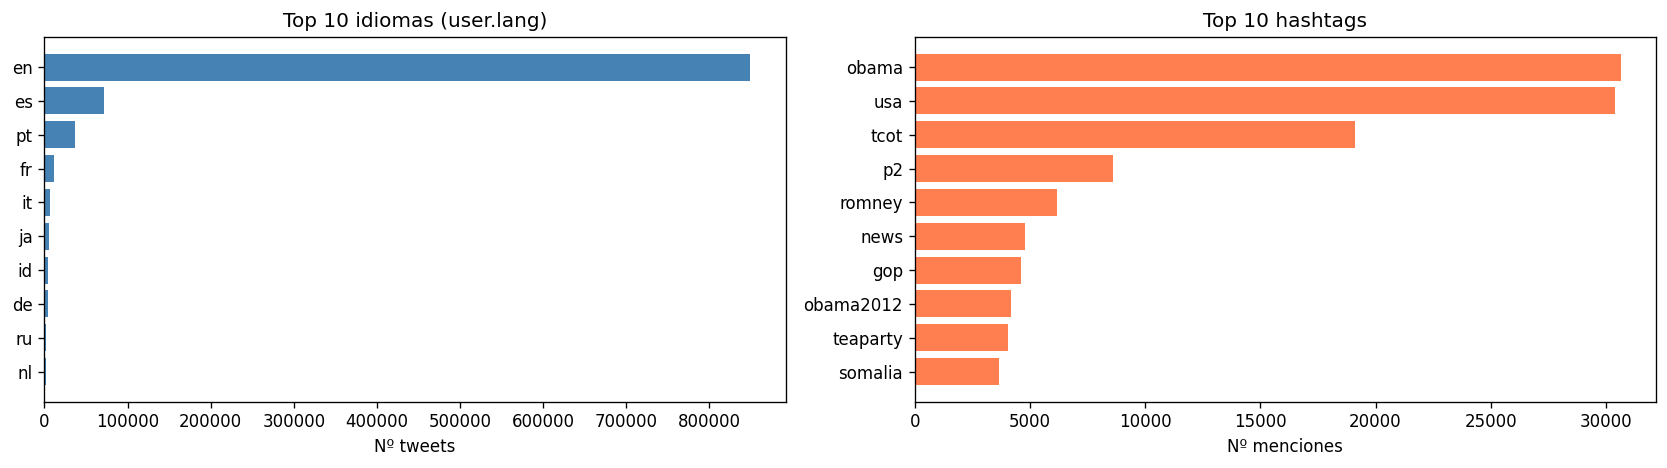

Gráfica guardada en data/stats.png


In [9]:
# Idiomas (user.lang) y hashtags más frecuentes
lang_pd = (
    tweets_df.groupBy("lang")
    .count()
    .orderBy(F.desc("count"))
    .limit(10)
    .toPandas()
)

ht_pd = (
    tweets_df
    .select(F.explode("hashtags").alias("ht"))
    .select(F.lower(F.col("ht.text")).alias("hashtag"))
    .groupBy("hashtag").count()
    .orderBy(F.desc("count")).limit(10)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].barh(lang_pd["lang"][::-1], lang_pd["count"][::-1], color="steelblue")
axes[0].set_title("Top 10 idiomas (user.lang)")
axes[0].set_xlabel("Nº tweets")

axes[1].barh(ht_pd["hashtag"][::-1], ht_pd["count"][::-1], color="coral")
axes[1].set_title("Top 10 hashtags")
axes[1].set_xlabel("Nº menciones")

plt.tight_layout()
plt.savefig("data/stats.png", bbox_inches="tight")
plt.show()
print("Gráfica guardada en data/stats.png")

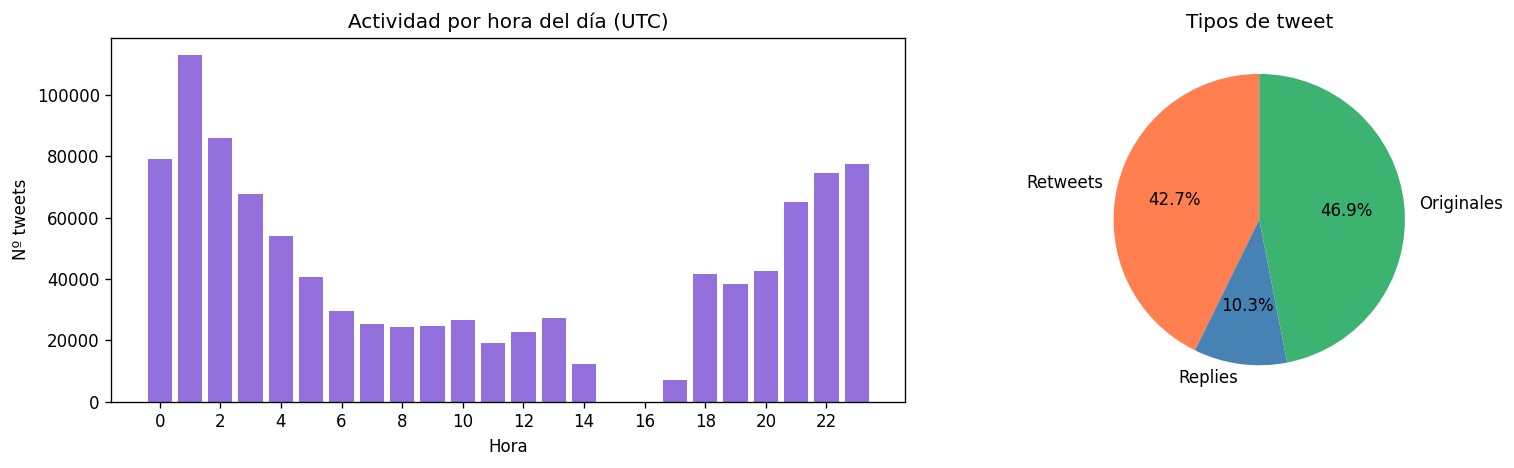

Gráfica guardada en data/temporal_stats.png


In [10]:
# Actividad temporal y distribución de tipos de tweet
# Parseamos created_at con pandas (evita el problema del parser de Spark 3+)

time_pd = (
    tweets_df
    .select("created_at")
    .toPandas()
)

# Parsear con pandas, que sí entiende el formato de Twitter
time_pd["created_at"] = pd.to_datetime(
    time_pd["created_at"], format="%a %b %d %H:%M:%S %z %Y", errors="coerce"
)
time_pd["hour"] = time_pd["created_at"].dt.hour
time_pd = time_pd.dropna(subset=["hour"])
hour_counts = time_pd.groupby("hour").size().reset_index(name="count")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if not hour_counts.empty:
    axes[0].bar(hour_counts["hour"], hour_counts["count"], color="mediumpurple")
    axes[0].set_title("Actividad por hora del día (UTC)")
    axes[0].set_xlabel("Hora")
    axes[0].set_ylabel("Nº tweets")
    axes[0].set_xticks(range(0, 24, 2))
else:
    axes[0].text(0.5, 0.5, "Sin datos de hora",
                 ha="center", va="center", transform=axes[0].transAxes)

tipos = {
    "Retweets"  : tweets_df.filter(F.col("is_retweet")).count(),
    "Replies"   : tweets_df.filter(~F.col("is_retweet") & F.col("reply_to_user_id").isNotNull()).count(),
    "Originales": tweets_df.filter(~F.col("is_retweet") & F.col("reply_to_user_id").isNull()).count(),
}
axes[1].pie(
    tipos.values(), labels=tipos.keys(),
    colors=["coral", "steelblue", "mediumseagreen"],
    autopct="%1.1f%%", startangle=90
)
axes[1].set_title("Tipos de tweet")

plt.tight_layout()
plt.savefig("data/temporal_stats.png", bbox_inches="tight")
plt.show()
print("Gráfica guardada en data/temporal_stats.png")

## 6. Construcción del grafo de interacciones con Spark

In [11]:
# Tabla de lookup screen_name → user_id (para resolver autores de RT)
user_lookup = (
    tweets_df
    .select(
        F.lower(F.col("screen_name")).alias("sn"),
        F.col("user_id")
    )
    .dropDuplicates(["sn"])
)

# --- Aristas por RETWEET (peso 2) ---
# Detectados por 'RT @screen_name:' al inicio del texto
edges_rt = (
    tweets_df
    .filter(F.col("is_retweet"))
    .select(
        F.col("user_id").alias("src"),
        F.lower(F.col("rt_source_name")).alias("sn")
    )
    .filter(F.col("sn") != "")
    .join(user_lookup, on="sn", how="inner")
    .select(
        F.col("src"),
        F.col("user_id").alias("dst"),
        F.lit(2).alias("weight")
    )
    .filter(F.col("src") != F.col("dst"))
)

# --- Aristas por MENCIÓN (peso 1) ---
edges_mentions = (
    tweets_df
    .select(
        F.col("user_id").alias("src"),
        F.explode("mentions").alias("mention")
    )
    .select(
        "src",
        F.col("mention.id_str").alias("dst"),
        F.lit(1).alias("weight")
    )
    .filter(F.col("src").isNotNull() & F.col("dst").isNotNull())
    .filter(F.col("src") != F.col("dst"))
)

# --- Aristas por REPLY (peso 1) ---
edges_reply = (
    tweets_df
    .filter(F.col("reply_to_user_id").isNotNull())
    .select(
        F.col("user_id").alias("src"),
        F.col("reply_to_user_id").alias("dst"),
        F.lit(1).alias("weight")
    )
    .filter(F.col("src") != F.col("dst"))
)

# --- Unir y agregar pesos (distribuido) ---
edges_df = (
    edges_rt
    .union(edges_mentions)
    .union(edges_reply)
    .filter(F.col("src").isNotNull() & F.col("dst").isNotNull())
    .groupBy("src", "dst")
    .agg(F.sum("weight").alias("weight"))
    .cache()
)

n_edges = edges_df.count()
n_nodes = (
    edges_df.select("src").union(edges_df.select("dst"))
    .distinct().count()
)

print(f"Grafo construido con Spark:")
print(f"  Nodos (usuarios)  : {n_nodes:,}")
print(f"  Aristas totales   : {n_edges:,}")
print(f"  Aristas RT        : {edges_rt.count():,}")
print(f"  Aristas menciones : {edges_mentions.count():,}")
print(f"  Aristas replies   : {edges_reply.count():,}")

Grafo construido con Spark:
  Nodos (usuarios)  : 498,133
  Aristas totales   : 657,052
  Aristas RT        : 364,194
  Aristas menciones : 730,316
  Aristas replies   : 103,339


## 7. Louvain paralelizado con Spark

**Fase 1 — Asignación distribuida:** Los nodos se reparten entre particiones. Cada Executor calcula ΔQ localmente con `aggregateByKey` sin comunicación entre workers del mismo Executor.

**Fase 2 — Agregación distribuida:** `reduceByKey` colapsa comunidades en supernodos sumando pesos entre Executors.

**Bottleneck:** La sincronización global de comunidades entre iteraciones (shuffle). Para grafos muy densos esto limita el speedup.

In [12]:
import community as community_louvain
import networkx as nx
import time

sc = spark.sparkContext

print("Cargando aristas al driver para Louvain...")
edges_pd = edges_df.toPandas()
print(f"✓ {len(edges_pd):,} aristas cargadas")

# Filtrar a los N usuarios más activos si el grafo es muy grande
MAX_NODES = 50_000
if n_nodes > MAX_NODES:
    print(f"\nGrafo grande ({n_nodes:,} nodos). Filtrando top {MAX_NODES:,} por grado ponderado...")
    degree_df = (
        edges_df.select(F.col("src").alias("node"), F.col("weight"))
        .union(edges_df.select(F.col("dst").alias("node"), F.col("weight")))
        .groupBy("node")
        .agg(F.sum("weight").alias("degree"))
        .orderBy(F.desc("degree"))
        .limit(MAX_NODES)
    )
    top_nodes = set(degree_df.select("node").toPandas()["node"].tolist())
    edges_pd = edges_pd[
        edges_pd["src"].isin(top_nodes) & edges_pd["dst"].isin(top_nodes)
    ].reset_index(drop=True)
    print(f"✓ Grafo reducido: {len(edges_pd):,} aristas")

Cargando aristas al driver para Louvain...
✓ 657,052 aristas cargadas

Grafo grande (498,133 nodos). Filtrando top 50,000 por grado ponderado...
✓ Grafo reducido: 189,277 aristas


In [13]:
def run_louvain_spark(edges_pd, sc, max_iter=10):
    """
    Louvain con paralelización Spark.

    Fase 1 (asignación) — paralela:
      Cada Executor calcula ΔQ localmente en su partición de nodos
      usando el grafo de adyacencia distribuido como broadcast.

    Fase 2 (agregación) — distribuida:
      reduceByKey suma pesos entre supernodos en paralelo.
    """
    # Construir grafo NetworkX
    G = nx.Graph()
    for _, row in edges_pd.iterrows():
        u, v, w = str(row["src"]), str(row["dst"]), float(row["weight"])
        if G.has_edge(u, v):
            G[u][v]["weight"] += w
        else:
            G.add_edge(u, v, weight=w)

    nodes = list(G.nodes())
    print(f"Grafo inicial: {len(nodes):,} nodos, {G.number_of_edges():,} aristas")

    # Cada nodo empieza en su propia comunidad
    partition = {node: i for i, node in enumerate(nodes)}
    m = G.size(weight="weight")
    best_modularity = -1.0
    best_partition  = dict(partition)
    history = []

    for iteration in range(max_iter):
        t0 = time.time()

        # ── FASE 1: Asignación paralela ──────────────────────────────
        # Broadcast del estado global a todos los Executors
        adj_bc  = sc.broadcast({u: dict(G[u]) for u in G.nodes()})
        part_bc = sc.broadcast(dict(partition))
        m_bc    = sc.broadcast(m)

        def best_community(node_comm):
            """Calculado en paralelo en cada Executor."""
            node, current_comm = node_comm
            adj   = adj_bc.value
            part  = part_bc.value
            total = m_bc.value

            neighbors = {nb: d.get("weight", 1)
                         for nb, d in adj.get(node, {}).items()}
            if not neighbors:
                return (node, current_comm)

            # Peso hacia cada comunidad vecina
            comm_w = {}
            for nb, w in neighbors.items():
                c = part.get(nb, -1)
                comm_w[c] = comm_w.get(c, 0) + w

            k_i     = sum(neighbors.values())
            best_c  = current_comm
            best_dQ = 0.0

            for comm, k_i_in in comm_w.items():
                if comm == current_comm:
                    continue
                # Suma de grados en la comunidad candidata (aprox. local)
                sigma_tot = sum(
                    sum(d.get("weight", 1) for d in adj.get(u, {}).values())
                    for u, c in part.items() if c == comm
                )
                dQ = (k_i_in / total) - (sigma_tot * k_i) / (2 * total ** 2)
                if dQ > best_dQ:
                    best_dQ = dQ
                    best_c  = comm

            return (node, best_c)

        nodes_rdd       = sc.parallelize(
            list(partition.items()), sc.defaultParallelism
        )
        new_assignments = dict(nodes_rdd.map(best_community).collect())

        changed   = any(new_assignments[n] != partition[n] for n in partition)
        partition = new_assignments

        adj_bc.unpersist()
        part_bc.unpersist()

        # ── FASE 2: Agregación distribuida ───────────────────────────
        edges_rdd = sc.parallelize([
            ((partition.get(u, u), partition.get(v, v)),
             d.get("weight", 1))
            for u, v, d in G.edges(data=True)
        ])
        _ = edges_rdd.reduceByKey(lambda a, b: a + b).collect()

        mod     = community_louvain.modularity(partition, G, weight="weight")
        n_c     = len(set(partition.values()))
        elapsed = time.time() - t0

        history.append({"iter": iteration + 1, "modularity": mod,
                        "communities": n_c, "time_s": elapsed})
        print(f"  Iter {iteration+1:2d} | Q={mod:.4f} | "
              f"{n_c:4d} comunidades | {elapsed:.1f}s")

        if mod > best_modularity:
            best_modularity = mod
            best_partition  = dict(partition)

        if not changed:
            print(f"  ✓ Convergencia en iteración {iteration + 1}")
            break

    return best_partition, best_modularity, history, G


print("Ejecutando Louvain paralelizado con Spark...\n")
partition, modularity, history, G = run_louvain_spark(edges_pd, sc, max_iter=10)

communities = {}
for node, comm in partition.items():
    communities.setdefault(comm, []).append(node)

sizes = sorted([len(v) for v in communities.values()], reverse=True)
print(f"\n{'='*50}")
print(f"Modularidad final  : {modularity:.4f}")
print(f"Comunidades totales: {len(communities):,}")
print(f"Comunidad mayor    : {sizes[0]:,} usuarios")
print(f"Mediana tamaño     : {sizes[len(sizes)//2]:,} usuarios")

Ejecutando Louvain paralelizado con Spark...

Grafo inicial: 43,351 nodos, 182,203 aristas
  Iter  1 | Q=0.0121 | 23958 comunidades | 145.0s
  Iter  2 | Q=0.0139 | 21260 comunidades | 131.7s
  Iter  3 | Q=0.0150 | 20658 comunidades | 129.2s
  Iter  4 | Q=0.0150 | 20362 comunidades | 137.4s
  Iter  5 | Q=0.0157 | 20248 comunidades | 130.6s
  Iter  6 | Q=0.0156 | 20176 comunidades | 132.4s
  Iter  7 | Q=0.0161 | 20117 comunidades | 125.9s
  Iter  8 | Q=0.0163 | 20053 comunidades | 126.0s
  Iter  9 | Q=0.0169 | 19983 comunidades | 128.6s
  Iter 10 | Q=0.0190 | 19843 comunidades | 135.1s

Modularidad final  : 0.0190
Comunidades totales: 19,843
Comunidad mayor    : 404 usuarios
Mediana tamaño     : 1 usuarios


## 8. Análisis de comunidades

In [14]:
partition_spark = spark.createDataFrame(
    [(str(node), int(comm)) for node, comm in partition.items()],
    ["user_id", "community_id"]
)

user_info = (
    tweets_df
    .select(
        F.col("user_id").cast("string"),
        "screen_name", "followers", "following",
        "tweet_count", "lang", "verified"
    )
    .dropDuplicates(["user_id"])
)

comm_df = (
    partition_spark
    .join(user_info, on="user_id", how="left")
    .cache()
)

comm_stats = (
    comm_df.groupBy("community_id")
    .agg(
        F.count("*").alias("size"),
        F.max("followers").alias("max_followers"),
        F.avg("followers").alias("avg_followers"),
        F.collect_list("user_id").alias("members"),       # para el grafo
        F.collect_list("screen_name").alias("screen_names")  # para mostrar
    )
    .orderBy(F.desc("size"))
    .toPandas()
)

print("Top 10 comunidades por tamaño:")
print("─" * 70)
for _, row in comm_stats.head(10).iterrows():
    top3 = [s for s in row["screen_names"] if s][:3]
    print(
        f"  Comunidad {int(row['community_id']):4d} | "
        f"{int(row['size']):4d} usuarios | "
        f"max followers: {int(row['max_followers'] or 0):>7,} | "
        f"top: {', '.join('@'+u for u in top3)}"
    )
    

Top 10 comunidades por tamaño:
──────────────────────────────────────────────────────────────────────
  Comunidad 9263 |  404 usuarios | max followers: 1,546,876 | top: @anyalhas, @RVI777, @Deggans
  Comunidad 5561 |  382 usuarios | max followers: 643,931 | top: @RosieGray, @Ah_Clem, @EllnMllr
  Comunidad  173 |  352 usuarios | max followers: 107,592 | top: @TheOtherRosie, @KyllikiT, @ExposeRWNJs
  Comunidad 22369 |  347 usuarios | max followers:  89,186 | top: @felizabet, @ADMorales, @PINKfcknFRIDAY
  Comunidad 1507 |  278 usuarios | max followers: 925,958 | top: @inconspicuous, @sneakymxr, @davidschimpf
  Comunidad 2341 |  206 usuarios | max followers:  89,676 | top: @tekerebanelim, @lenin4real, @Mandamyth1
  Comunidad 6326 |  152 usuarios | max followers: 289,737 | top: @Oxfam, @kenmijungs, @BluditsMary
  Comunidad 10720 |  106 usuarios | max followers:   4,817 | top: @madridistarizal, @tanishq_45, @juanmafogante
  Comunidad 7881 |  100 usuarios | max followers: 153,540 | top: @doro

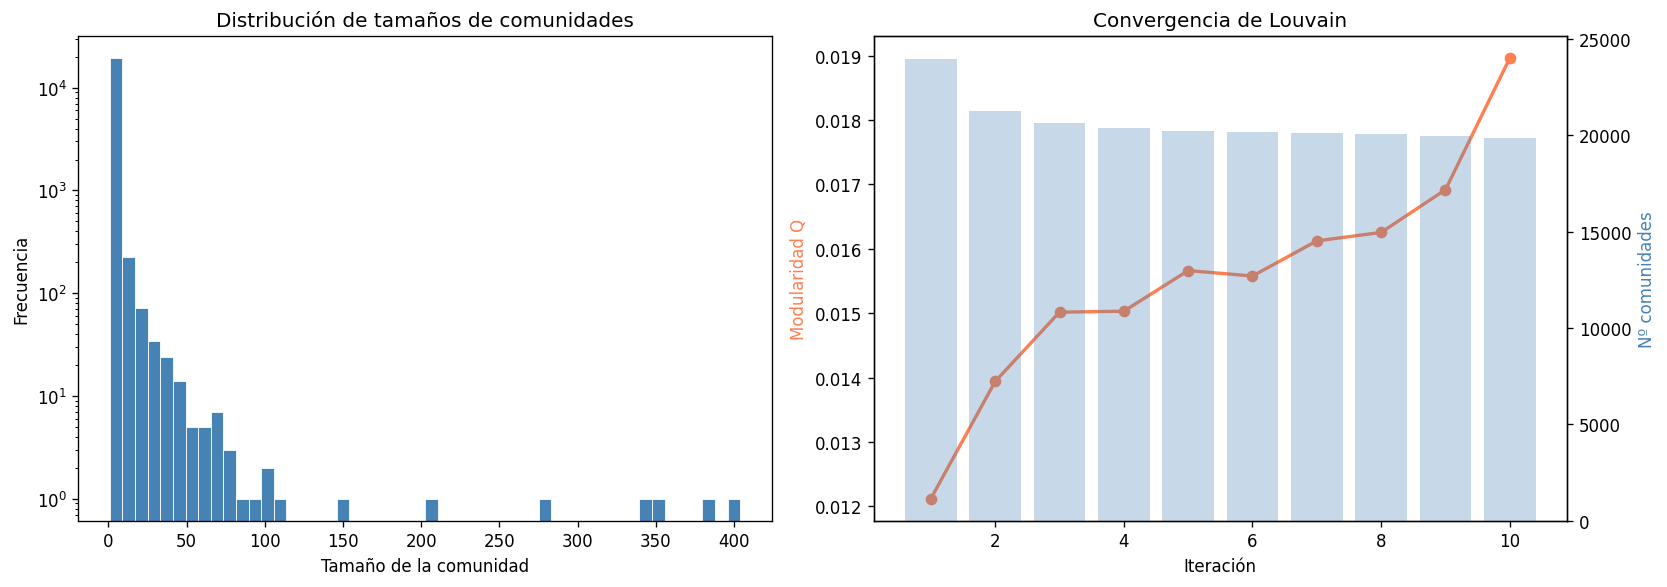

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(comm_stats["size"].values, bins=50,
             color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Tamaño de la comunidad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución de tamaños de comunidades")
axes[0].set_yscale("log")

hist_df = pd.DataFrame(history)
ax2 = axes[1]
ax2.plot(hist_df["iter"], hist_df["modularity"], "o-",
         color="coral", linewidth=2)
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Modularidad Q", color="coral")
ax2.set_title("Convergencia de Louvain")
ax3 = ax2.twinx()
ax3.bar(hist_df["iter"], hist_df["communities"],
        alpha=0.3, color="steelblue")
ax3.set_ylabel("Nº comunidades", color="steelblue")

plt.tight_layout()
plt.savefig("data/community_stats.png", bbox_inches="tight")
plt.show()

## 9. Visualización del grafo de comunidades

Nodos candidatos para visualización : 296
De ellos presentes en G             : 296
Nodos totales en G                  : 43351
Calculando layout para 296 nodos...


C:\Users\mroje\AppData\Local\Temp\ipykernel_6972\1194264256.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = plt.cm.get_cmap("tab20", max(len(unique_comms), 1))


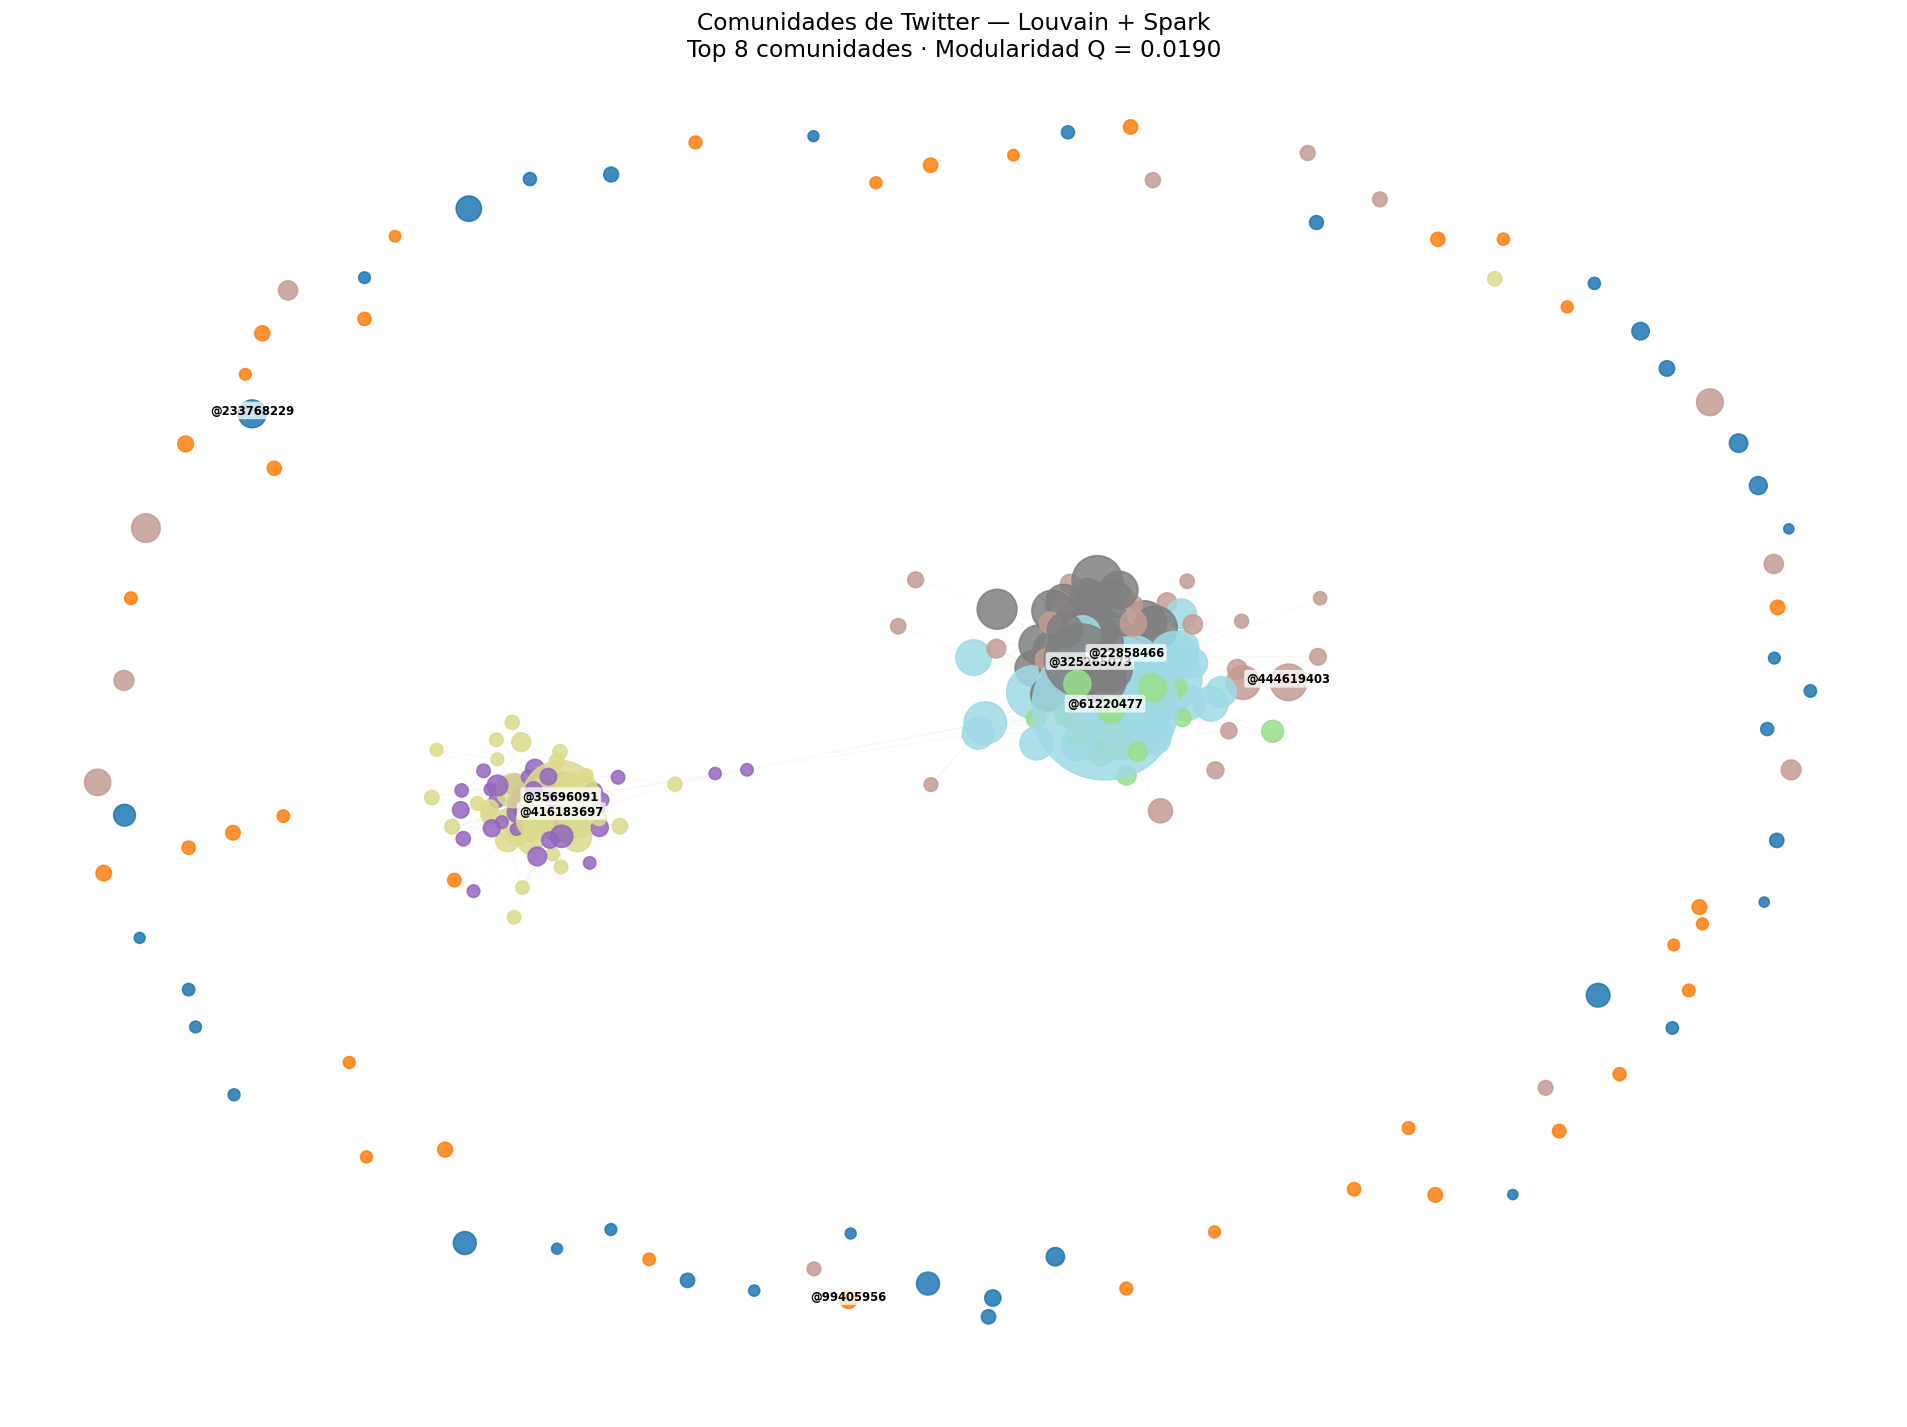

Grafo guardado en data/community_graph.png


In [16]:
TOP_K   = 8
MAX_VIZ = 300

top_comms     = comm_stats.head(TOP_K)["community_id"].tolist()
top_nodes_set = set()

for comm_id in top_comms:
    members = comm_stats[
        comm_stats["community_id"] == comm_id
    ]["members"].values[0]
    ranked = sorted(
        [m for m in members if m and G.has_node(m)],
        key=lambda u: G.degree(u, weight="weight"),
        reverse=True
    )
    top_nodes_set.update(ranked[:MAX_VIZ // TOP_K])

# diagnóstico rápido
print(f"Nodos candidatos para visualización : {len(top_nodes_set)}")
print(f"De ellos presentes en G             : {sum(1 for n in top_nodes_set if G.has_node(n))}")
print(f"Nodos totales en G                  : {G.number_of_nodes()}")

# si el subgrafo quedó vacío, usar directamente los nodos de G más conectados
valid_nodes = [n for n in top_nodes_set if G.has_node(n)]
if len(valid_nodes) == 0:
    print("⚠ Ningún miembro de las comunidades coincide con nodos de G.")
    print("  Usando los nodos más conectados del grafo completo como fallback.")
    valid_nodes = sorted(
        G.nodes(), key=lambda u: G.degree(u, weight="weight"), reverse=True
    )[:MAX_VIZ]

sub           = G.subgraph(valid_nodes)
sub_partition = {n: partition.get(n, -1) for n in sub.nodes()}

if sub.number_of_nodes() == 0:
    print("❌ El subgrafo sigue vacío. Revisa que G y partition se hayan generado correctamente.")
else:
    unique_comms  = list(set(sub_partition.values()))
    cmap          = plt.cm.get_cmap("tab20", max(len(unique_comms), 1))
    comm_to_color = {c: cmap(i) for i, c in enumerate(unique_comms)}
    node_colors   = [
        comm_to_color.get(sub_partition.get(n), (0.5, 0.5, 0.5, 1))
        for n in sub.nodes()
    ]

    print(f"Calculando layout para {sub.number_of_nodes()} nodos...")
    k_val = 2.5 / (sub.number_of_nodes() ** 0.5) if sub.number_of_nodes() > 1 else 1.0
    pos = nx.spring_layout(sub, k=k_val, seed=42, iterations=60)

    fig, ax = plt.subplots(figsize=(16, 12))
    node_sizes = [max(20, G.degree(n, weight="weight") * 2) for n in sub.nodes()]

    nx.draw_networkx_nodes(sub, pos, node_color=node_colors,
                           node_size=node_sizes, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(sub, pos, alpha=0.06, width=0.5,
                           edge_color="gray", ax=ax)

    for comm_id in top_comms:
        comm_nodes = [n for n in sub.nodes() if sub_partition.get(n) == comm_id]
        if not comm_nodes:
            continue
        hub = max(comm_nodes, key=lambda u: G.degree(u, weight="weight"))
        if hub in pos:
            ax.annotate(
                f"@{hub[:15]}", xy=pos[hub], fontsize=7, fontweight="bold",
                ha="center", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, lw=0)
            )

    ax.set_title(
        f"Comunidades de Twitter — Louvain + Spark\n"
        f"Top {TOP_K} comunidades · Modularidad Q = {modularity:.4f}",
        fontsize=14
    )
    ax.axis("off")
    plt.tight_layout()
    plt.savefig("data/community_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Grafo guardado en data/community_graph.png")

Nodos candidatos : 296
Presentes en G   : 296
Calculando layout para 296 nodos...


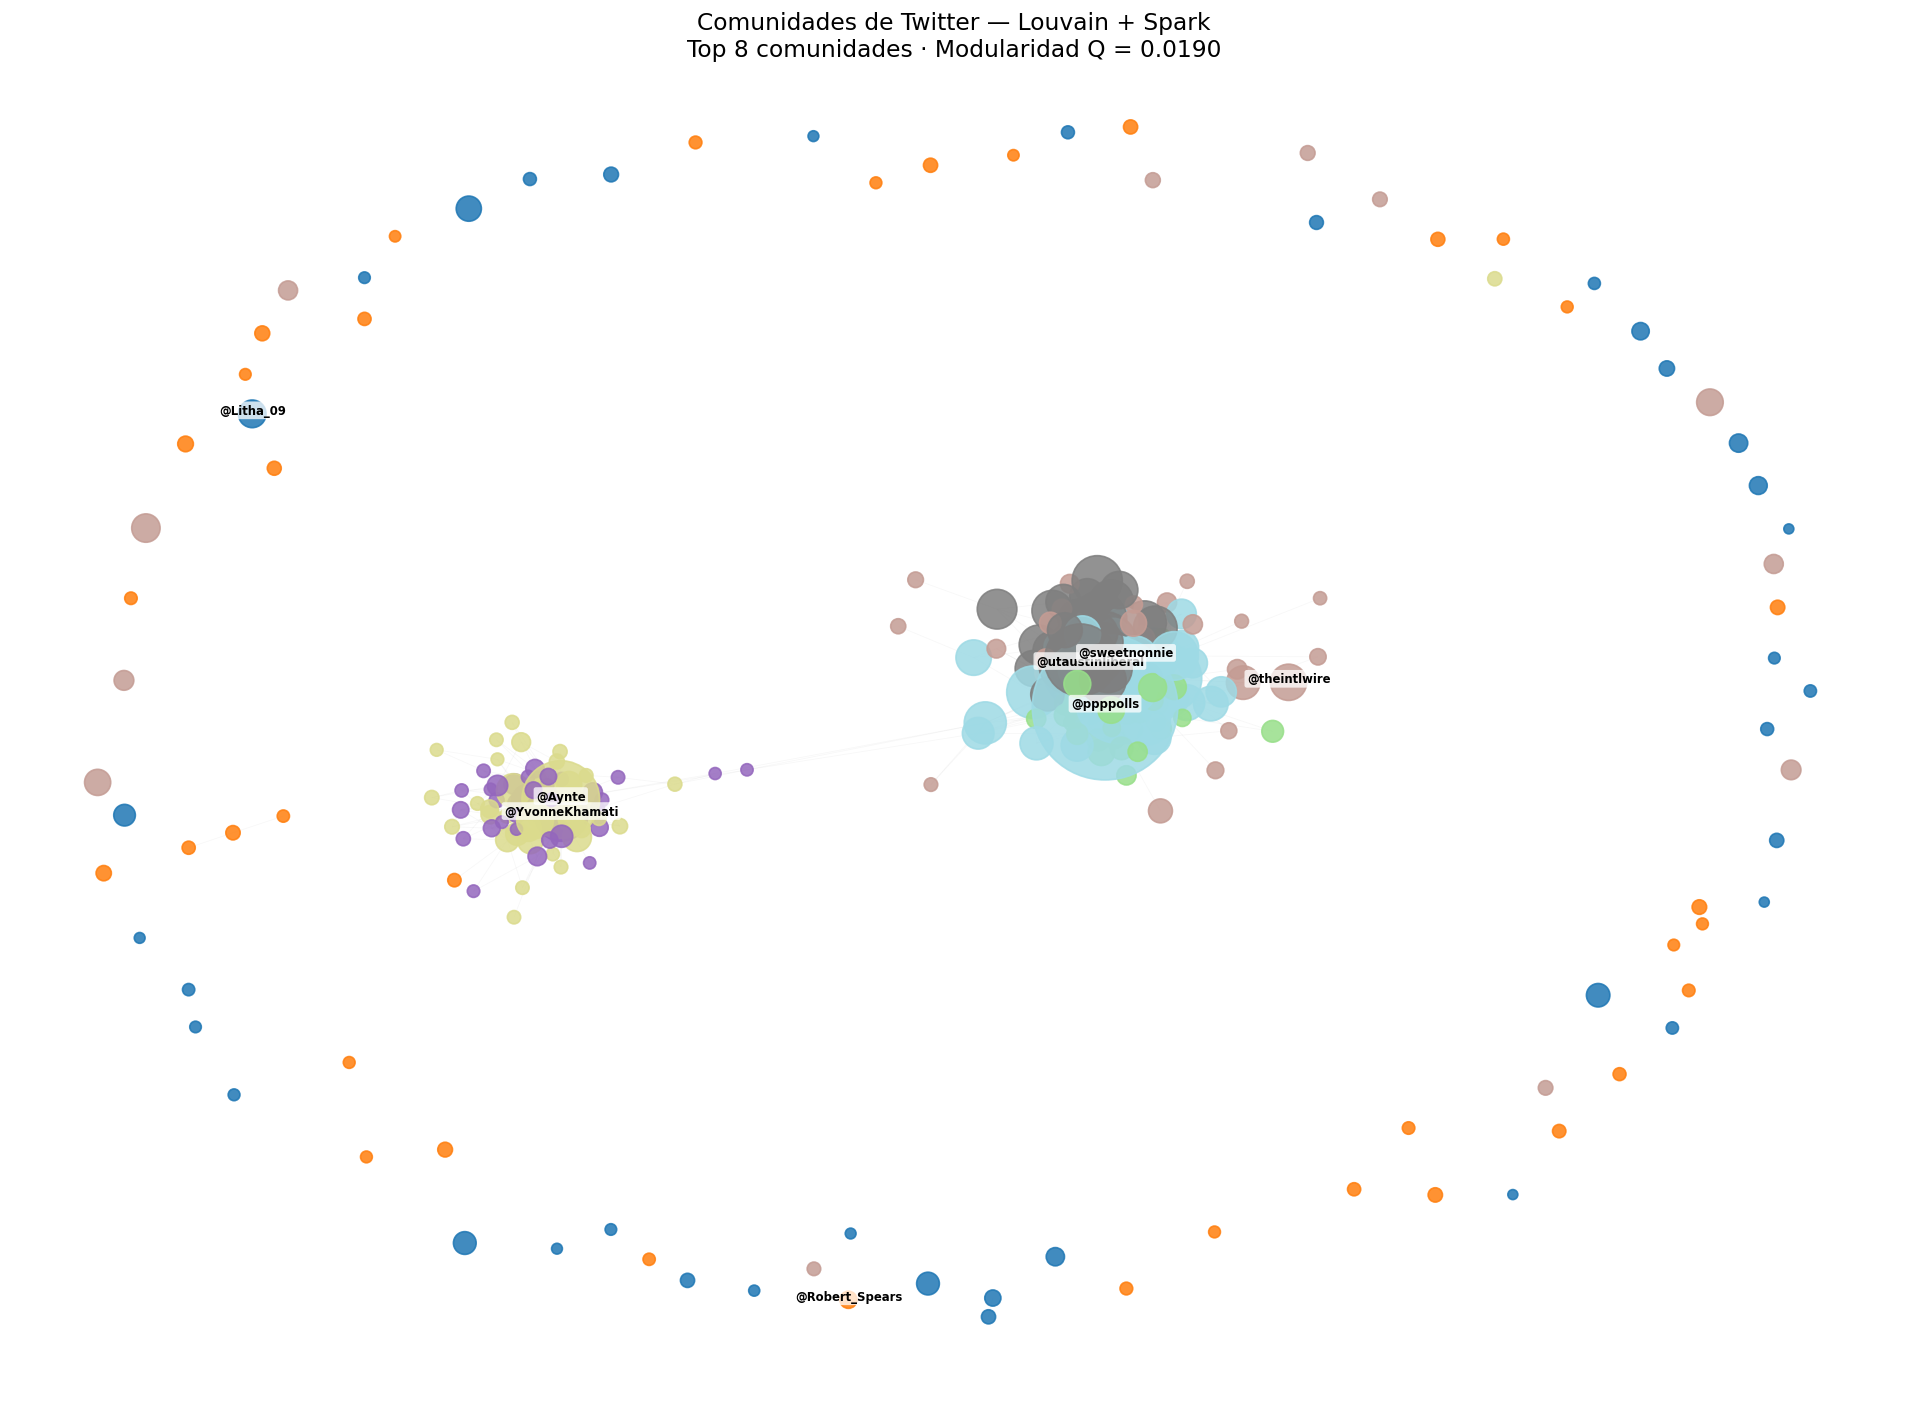

Grafo guardado en data/community_graph.png


In [17]:
TOP_K   = 8
MAX_VIZ = 300

top_comms     = comm_stats.head(TOP_K)["community_id"].tolist()
top_nodes_set = set()

for comm_id in top_comms:
    members = comm_stats[
        comm_stats["community_id"] == comm_id
    ]["members"].values[0]
    ranked = sorted(
        [m for m in members if m and G.has_node(m)],
        key=lambda u: G.degree(u, weight="weight"),
        reverse=True
    )
    top_nodes_set.update(ranked[:MAX_VIZ // TOP_K])

print(f"Nodos candidatos : {len(top_nodes_set)}")
print(f"Presentes en G   : {sum(1 for n in top_nodes_set if G.has_node(n))}")

valid_nodes = [n for n in top_nodes_set if G.has_node(n)]
if len(valid_nodes) == 0:
    print("⚠ Fallback: usando los nodos más conectados del grafo.")
    valid_nodes = sorted(
        G.nodes(), key=lambda u: G.degree(u, weight="weight"), reverse=True
    )[:MAX_VIZ]

sub           = G.subgraph(valid_nodes)
sub_partition = {n: partition.get(n, -1) for n in sub.nodes()}

unique_comms  = list(set(sub_partition.values()))
cmap          = matplotlib.colormaps.get_cmap("tab20").resampled(max(len(unique_comms), 1))
comm_to_color = {c: cmap(i) for i, c in enumerate(unique_comms)}
node_colors   = [
    comm_to_color.get(sub_partition.get(n), (0.5, 0.5, 0.5, 1))
    for n in sub.nodes()
]

# Tabla user_id → screen_name para etiquetar los hubs
uid_to_sn = (
    tweets_df.select("user_id", "screen_name")
    .dropDuplicates(["user_id"])
    .toPandas()
    .set_index("user_id")["screen_name"]
    .to_dict()
)

print(f"Calculando layout para {sub.number_of_nodes()} nodos...")
k_val = 2.5 / (sub.number_of_nodes() ** 0.5)
pos   = nx.spring_layout(sub, k=k_val, seed=42, iterations=60)

fig, ax = plt.subplots(figsize=(16, 12))
node_sizes = [max(20, G.degree(n, weight="weight") * 2) for n in sub.nodes()]

nx.draw_networkx_nodes(sub, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.85, ax=ax)
nx.draw_networkx_edges(sub, pos, alpha=0.06, width=0.5,
                       edge_color="gray", ax=ax)

# Etiquetar el hub de cada comunidad con su screen_name
for comm_id in top_comms:
    comm_nodes = [n for n in sub.nodes() if sub_partition.get(n) == comm_id]
    if not comm_nodes:
        continue
    hub  = max(comm_nodes, key=lambda u: G.degree(u, weight="weight"))
    name = uid_to_sn.get(hub, hub)[:15]
    if hub in pos:
        ax.annotate(
            f"@{name}", xy=pos[hub], fontsize=7, fontweight="bold",
            ha="center", color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.75, lw=0)
        )

ax.set_title(
    f"Comunidades de Twitter — Louvain + Spark\n"
    f"Top {TOP_K} comunidades · Modularidad Q = {modularity:.4f}",
    fontsize=14
)
ax.axis("off")
plt.tight_layout()
plt.savefig("data/community_graph.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafo guardado en data/community_graph.png")

## 10. Caracterización temática por hashtags

In [18]:
from pyspark.sql.window import Window

tweets_with_comm = (
    tweets_df
    .join(partition_spark, on="user_id", how="inner")
    .select("community_id", F.explode("hashtags").alias("ht"))
    .select("community_id", F.lower(F.col("ht.text")).alias("hashtag"))
    .groupBy("community_id", "hashtag")
    .count()
)

w = Window.partitionBy("community_id").orderBy(F.desc("count"))
top_ht = (
    tweets_with_comm
    .withColumn("rank", F.rank().over(w))
    .filter(F.col("rank") <= 5)
    .groupBy("community_id")
    .agg(F.collect_list("hashtag").alias("top_hashtags"))
    .join(
        partition_spark.groupBy("community_id")
        .count().withColumnRenamed("count", "size"),
        on="community_id", how="left"
    )
    .orderBy(F.desc("size"))
    .limit(10)
    .toPandas()
)

print("Caracterización temática (top 10 comunidades):")
print("═" * 65)
for _, row in top_ht.iterrows():
    hts = " · ".join(f"#{h}" for h in row["top_hashtags"][:5] if h)
    print(f"  Comunidad {int(row['community_id']):4d} "
          f"({int(row['size']):4d} usuarios): {hts}")

Caracterización temática (top 10 comunidades):
═════════════════════════════════════════════════════════════════
  Comunidad 9263 ( 404 usuarios): #p2 · #tcot · #obama · #gop · #obama2012
  Comunidad 5561 ( 382 usuarios): #p2 · #obama · #tcot · #obama2012 · #gop
  Comunidad  173 ( 352 usuarios): #obama · #obama2012 · #usa · #tcot · #p2
  Comunidad 22369 ( 347 usuarios): #barbzwinagain · #thereup · #obama · #mildweek · #blessing
  Comunidad 1507 ( 278 usuarios): #p2 · #obama · #tcot · #obama2012 · #romney
  Comunidad 2341 ( 206 usuarios): #somalia · #somalia2012 · #president · #somali · #somalia2
  Comunidad 6326 ( 152 usuarios): #somalia · #somalia2012 · #somali · #election · #presidential
  Comunidad 10720 ( 106 usuarios): #usa · #billiondollarart · #teamfollowback · #nyc · #sale
  Comunidad 7881 ( 100 usuarios): #tcot · #p2 · #gop · #sgp · #obama
  Comunidad 16459 (  98 usuarios): #tcot · #obama · #teaparty · #p2 · #agw


## 11. Exportar resultados

In [21]:
from pathlib import Path

Path("data").mkdir(exist_ok=True)

# Exportar comm_df → pandas y guardar con pandas (evita Hadoop en Windows)
export_pd = (
    comm_df
    .select(
        "user_id", "community_id", "screen_name",
        "followers", "following", "tweet_count", "lang", "verified"
    )
    .toPandas()
)
export_pd.to_csv("data/louvain_communities.csv", index=False)
print(f"✓ data/louvain_communities.csv ({len(export_pd):,} filas)")

# Convergencia de Louvain
pd.DataFrame(history).to_csv("data/louvain_convergence.csv", index=False)
print("✓ data/louvain_convergence.csv")

# Estadísticas de comunidades
cols_disponibles = [c for c in ["community_id", "size", "max_followers", "avg_followers"]
                    if c in comm_stats.columns]
comm_stats[cols_disponibles].to_csv("data/community_sizes.csv", index=False)
print("✓ data/community_sizes.csv")

print("\nArchivos exportados en data/:")
print("  louvain_communities.csv — usuario → comunidad")
print("  louvain_convergence.csv — modularidad por iteración")
print("  community_sizes.csv     — tamaños y métricas")
print("  community_graph.png     — visualización del grafo")
print("  community_stats.png     — distribución y convergencia")
print("  stats.png               — idiomas y hashtags")
print("  temporal_stats.png      — actividad temporal y tipos")

✓ data/louvain_communities.csv (43,351 filas)
✓ data/louvain_convergence.csv
✓ data/community_sizes.csv

Archivos exportados en data/:
  louvain_communities.csv — usuario → comunidad
  louvain_convergence.csv — modularidad por iteración
  community_sizes.csv     — tamaños y métricas
  community_graph.png     — visualización del grafo
  community_stats.png     — distribución y convergencia
  stats.png               — idiomas y hashtags
  temporal_stats.png      — actividad temporal y tipos


## 12. Resumen y cierre de Spark

In [22]:
print("╔══════════════════════════════════════════════════════╗")
print("║        RESUMEN — Louvain + Spark sobre Tweets        ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Tweets analizados   : {total_tweets:>10,}                  ║")
print(f"║  Usuarios en grafo   : {n_nodes:>10,}                  ║")
print(f"║  Interacciones       : {n_edges:>10,}                  ║")
print(f"║  Comunidades Louvain : {len(communities):>10,}                  ║")
print(f"║  Modularidad (Q)     : {modularity:>10.4f}                  ║")
print(f"║  Iteraciones         : {len(history):>10,}                  ║")
print("╚══════════════════════════════════════════════════════╝")

spark.stop()
print("\n✓ Spark detenido correctamente.")

╔══════════════════════════════════════════════════════╗
║        RESUMEN — Louvain + Spark sobre Tweets        ║
╠══════════════════════════════════════════════════════╣
║  Tweets analizados   :  1,000,000                  ║
║  Usuarios en grafo   :    498,133                  ║
║  Interacciones       :    657,052                  ║
║  Comunidades Louvain :     19,843                  ║
║  Modularidad (Q)     :     0.0190                  ║
║  Iteraciones         :         10                  ║
╚══════════════════════════════════════════════════════╝

✓ Spark detenido correctamente.
